<a href="https://colab.research.google.com/github/Santa-And-Mo/Final_project_CV/blob/main/Star_Constellation_Detection_CV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FINAL PROJECT CV 2026

Constellation Detection and Recognition using Computer Vision

In [78]:
import os
import cv2
import numpy as np
import tensorflow as tf
# from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, Input, MaxPooling2D, BatchNormalization
# from tensorflow.keras import Model
from time import time

from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

# Set the seeds for reproducibility
from numpy.random import seed
# from tensorflow.random import set_seed
# seed_value = 1234578790
# seed(seed_value)
# set_seed(seed_value)

Text(0.5, 1.0, 'Original Image')

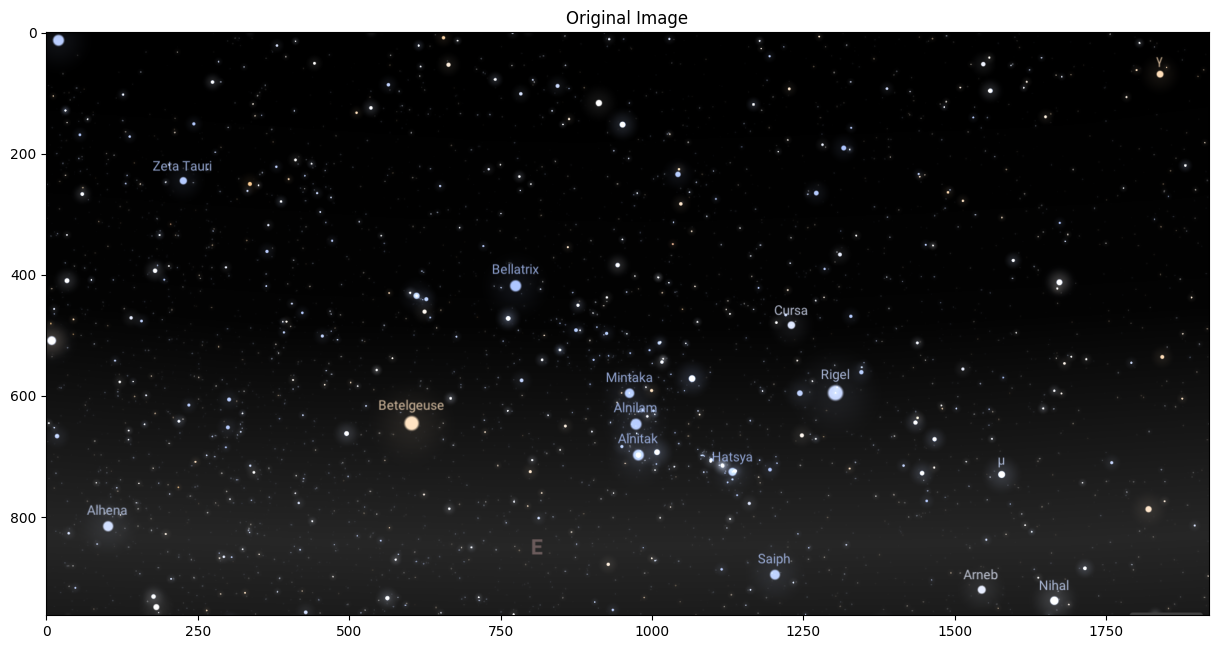

In [127]:
img = cv2.imread("/content/drive/MyDrive/Colab Notebooks/Star Constellation Detection CV project/data/Orion/img4.png")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
# plt.axis("off")

In [128]:
def resize_image(img, max_size=800):
    h, w = img.shape[:2]

    scale = max_size / max(h, w)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    return resized

Text(0.5, 1.0, 'Resized Image')

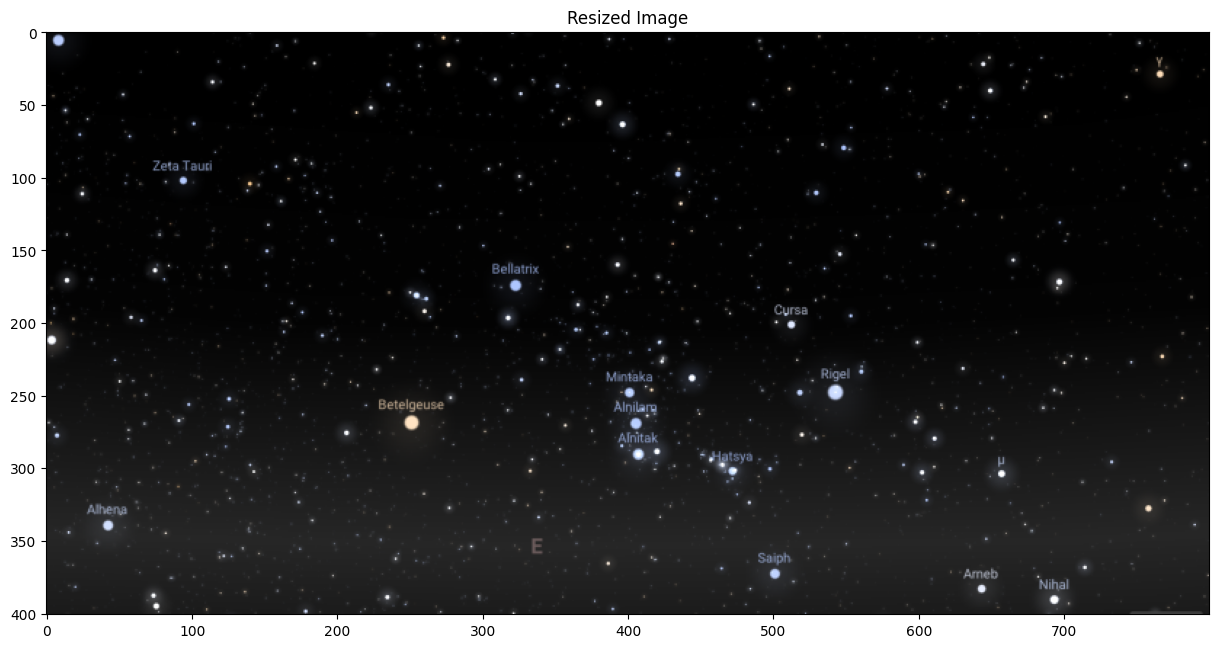

In [129]:

img = resize_image(img, max_size=800)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Resized Image")
# plt.axis("off")

In [22]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [154]:
def detect_stars_blob(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # трохи розмиваємо
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # налаштування blob detector
    params = cv2.SimpleBlobDetector_Params()

    params.filterByArea = True
    params.minArea = 10
    params.maxArea = 200

    params.filterByColor = True
    params.blobColor = 255  # шукаємо світлі точки

    params.filterByCircularity = True
    params.minCircularity = 0.8

    params.filterByInertia = True
    params.minInertiaRatio = 0.5

    params.filterByConvexity = True
    params.minConvexity = 0.9

    detector = cv2.SimpleBlobDetector_create(params)

    keypoints = detector.detect(blur)

    stars = [(int(k.pt[0]), int(k.pt[1])) for k in keypoints]

    return stars, keypoints

In [155]:
stars, keypoints = detect_stars_blob(img)

print("Stars detected:", len(stars))
print(stars)
# print(keypoints)

Stars detected: 40
[(643, 383), (713, 368), (386, 365), (757, 327), (610, 279), (519, 277), (7, 277), (206, 275), (518, 248), (400, 248), (443, 238), (423, 225), (3, 212), (512, 201), (317, 196), (259, 192), (322, 174), (696, 172), (13, 170), (392, 160), (93, 102), (396, 63), (379, 48), (649, 40), (765, 29), (8, 5), (234, 388), (42, 339), (602, 303), (407, 290), (419, 288), (74, 164), (693, 390), (500, 372), (656, 304), (251, 268), (542, 247), (74, 393), (405, 269), (469, 300)]


(np.float64(-0.5), np.float64(799.5), np.float64(400.5), np.float64(-0.5))

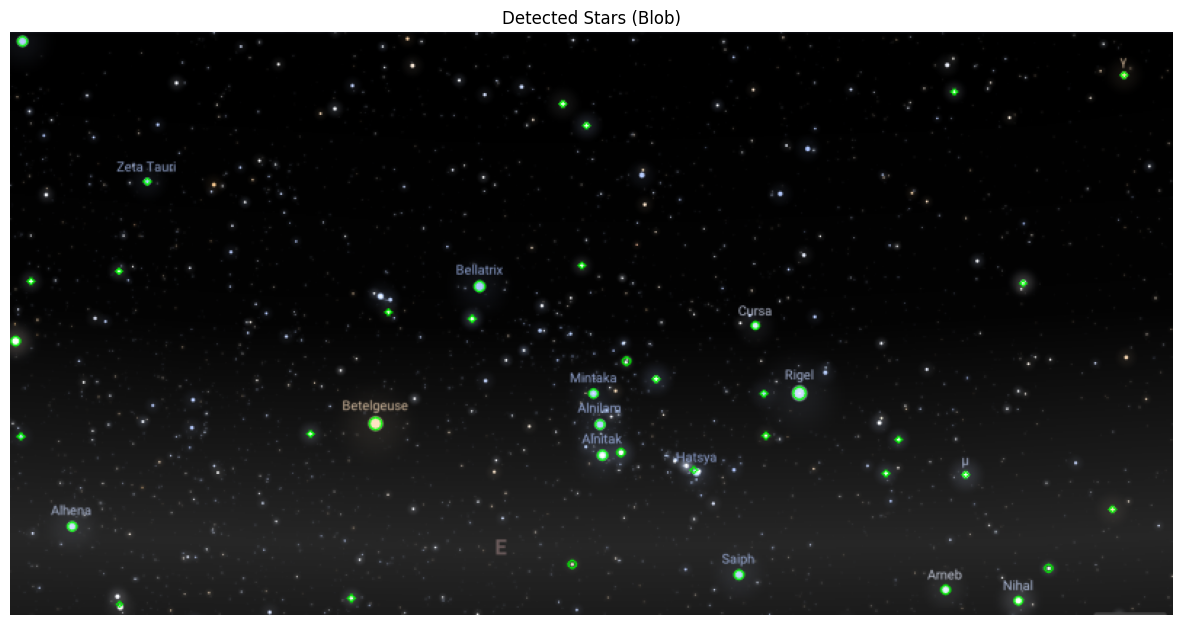

In [156]:
output = cv2.drawKeypoints(
    img,
    keypoints,
    None,
    (0,255,0),
    cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.imshow(output_rgb)
plt.title("Detected Stars (Blob)")
plt.axis("off")

In [161]:
output = img.copy()

# малюємо точки
for (x, y) in stars_sorted:
    cv2.circle(output, (x, y), 3, (0, 0, 255), -1)

# 🔥 з'єднуємо послідовно
for i in range(len(stars_sorted) - 1):
    x1, y1 = stars_sorted[i]
    x2, y2 = stars_sorted[i + 1]

    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 1)

Text(0.5, 1.0, 'Constellation')

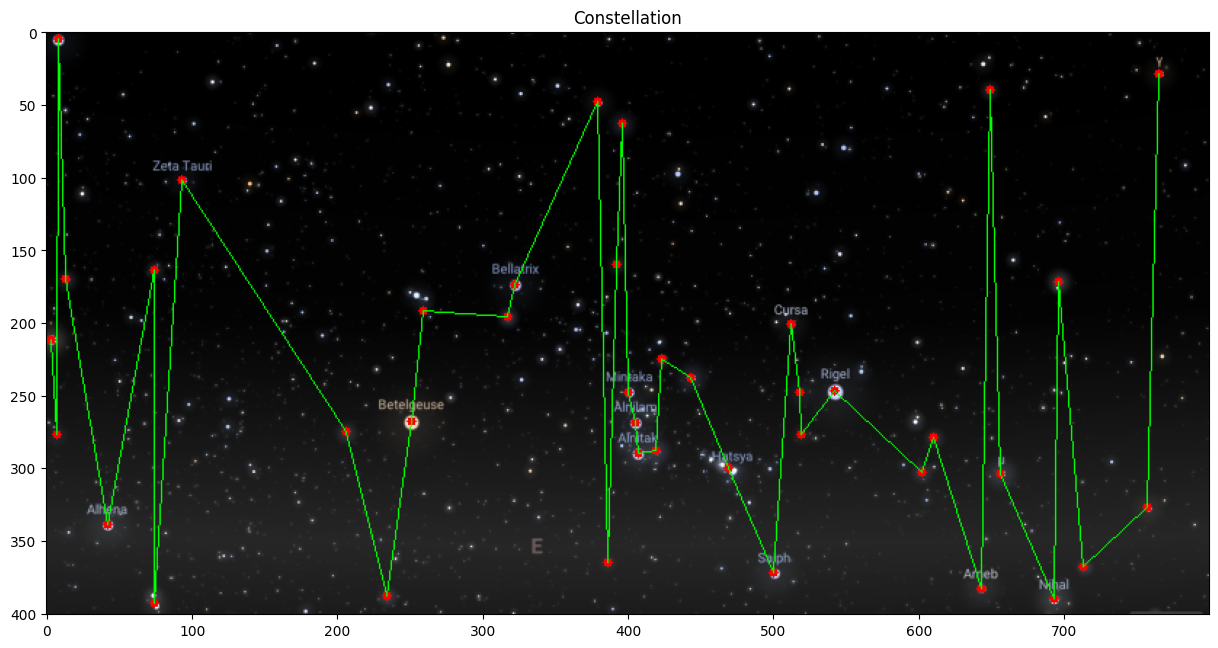

In [162]:
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.imshow(output_rgb)
plt.title("Constellation")
# plt.axis("off")